# EDA Steps:

**1- Column types:** Which columns are numbers but appear as objects in the dataset?

**2- Missing Data (NaNs):** Which columns have blanks, and is it a small fraction or half of the dataset?

**3- Outliers & Anomalies:** See if there are impossible min/max values (like a negative duration, or a date that makes no sense).

**4- Categorical Variables:** Which object columns are text categories that we will eventually need to encode into numbers?

**5- Target Variable Health:** Are there any missing values or weird imbalances in the target column?

**6- Multivariate Check:** Are there highly correlated features (collinearity) that might add redundant noise to the model?

**7- Data Leakage:** Do any columns contain future information or outcomes that the algorithm shouldn't have access to at the time of prediction?

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.5f' % x)

raw_data = pd.read_csv('../data/raw/data.dsv', sep = ';')

raw_data.head(10)

,ANNEE,MOIS,ID,NUM_REGISTRO,DATE_DOMICILIATION,DATE_ENREG_DO,DEVISE,FRET,FOB,ASSURANCE,FRAIS_ACCESSOIRE,CODE_SH,QUANTITE_DOMICILE,DATE_IMPUTATION,DATE_ENREG_IMP,QTE_IMPUTE
0,2015.00000,6.00000,8971,2015100000000707709,04-06-15,04-06-15,EUR,0.00000,68580.00000,0.00000,0.00000,3808911999,101600.00000,29-06-15,29-06-15,101600.00000
1,2015.00000,6.00000,22063,2015100000000719925,24-06-15,23-06-15,EUR,0.00000,29945.60000,0.00000,0.00000,6908900091,142380.00000,30-06-15,30-06-15,141396.00000
2,2015.00000,6.00000,24566,2015100000000722392,26-06-15,26-06-15,EUR,0.00000,8402.40000,0.00000,0.00000,4819509000,5903.00000,14-07-15,14-07-15,5903.00000
3,2015.00000,8.00000,79807,2015100000000773901,25-08-15,25-08-15,EUR,0.00000,3237.45000,0.00000,0.00000,6905100090,22813.00000,01-09-15,01-09-15,22813.00000
4,2015.00000,8.00000,59764,2015100000000754262,03-08-15,03-08-15,EUR,0.00000,56190.00000,0.00000,0.00000,8531200000,569.00000,26-08-15,26-08-15,569.00000
5,2015.00000,8.00000,74767,2015100000000768893,18-08-15,18-08-15,EUR,7376.00000,221118.43000,0.00000,0.00000,8212209000,3150.00000,02-09-15,02-09-15,3150.00000
6,2015.00000,7.00000,46153,2015100000000741321,20-07-15,20-07-15,AED,0.00000,105775.22000,0.00000,0.00000,6305101000,2.80000,17-08-15,17-08-15,2.80000
7,2015.00000,8.00000,63427,2015100000000757845,06-08-15,06-08-15,USD,1200.00000,8734.80000,0.00000,0.00000,6809190000,19916.00000,07-09-15,07-09-15,19916.00000
8,2015.00000,7.00000,48162,2015100000000743212,22-07-15,22-07-15,USD,21168.00000,36848.00000,0.00000,0.00000,2833110000,392000.00000,12-09-15,12-09-15,392000.00000
9,2015.00000,9.00000,114357,2015100000000808163,28-09-15,28-09-15,USD,61.98000,1176.80000,0.00000,0.00000,8473400080,0.70000,29-09-15,29-09-15,0.70000


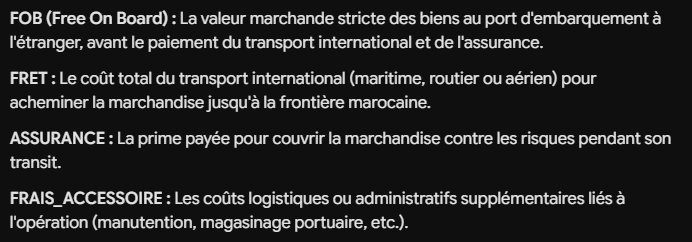

# **1- Columns type:**

In [2]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5320605 entries, 0 to 5320604
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ANNEE               float64
 1   MOIS                float64
 2   ID                  int64  
 3   NUM_REGISTRO        int64  
 4   DATE_DOMICILIATION  object 
 5   DATE_ENREG_DO       object 
 6   DEVISE              object 
 7   FRET                float64
 8   FOB                 float64
 9   ASSURANCE           float64
 10  FRAIS_ACCESSOIRE    float64
 11  CODE_SH             int64  
 12  QUANTITE_DOMICILE   float64
 13  DATE_IMPUTATION     object 
 14  DATE_ENREG_IMP      object 
 15  QTE_IMPUTE          float64
dtypes: float64(8), int64(3), object(5)
memory usage: 649.5+ MB


# **2- Missing Data (NaNs):**

In [3]:
# Affichage des colonnes ayant des valeurs manquantes, triées par pourcentage
missing_ratio = (raw_data.isnull().sum() / len(raw_data)) * 100
missing_data = missing_ratio[missing_ratio > 0].sort_values(ascending=False)
print("Pourcentage de valeurs manquantes par colonne :\n", missing_data)

Pourcentage de valeurs manquantes par colonne :
 DATE_ENREG_IMP       10.82685
ANNEE                 0.00284
MOIS                  0.00284
DATE_DOMICILIATION    0.00284
ASSURANCE             0.00008
FRET                  0.00004
dtype: float64


In [4]:
missing_ratio = (raw_data.isnull().sum() / len(raw_data))*100
has_missing_data = missing_ratio[missing_ratio > 0.002]
missing_data = has_missing_data.map('{:.3f}%'.format).to_frame(name='% missing data').reset_index(names='column')

missing_data.head()

,column,% missing data
0,ANNEE,0.003%
1,MOIS,0.003%
2,DATE_DOMICILIATION,0.003%
3,DATE_ENREG_IMP,10.827%


# **3- Outliers & Anomalies:**

In [5]:
raw_data.describe()

,ANNEE,MOIS,ID,NUM_REGISTRO,FRET,FOB,ASSURANCE,FRAIS_ACCESSOIRE,CODE_SH,QUANTITE_DOMICILE,QTE_IMPUTE
count,5320454.00000,5320454.00000,5320605.00000,5320605.00000,5320603.00000,5320605.00000,5320601.00000,5320605.00000,5320605.00000,5320605.00000,5320605.00000
mean,2019.48331,6.58966,2701913.11555,2019580626358338048.00000,16800.74546,369307.61325,137.16485,3.25796,6128467879.98754,6763548.15478,97519.58568
std,2.44360,3.51345,1499798.91632,2443282280570020.50000,311025.65263,4277710.17860,7619.11091,1346.95647,2585990203.56104,1956023736.64259,2558638.95976
min,2014.00000,1.00000,182.00000,2014100000000699904.00000,0.00000,0.00000,0.00000,0.00000,101210000.00000,0.00000,0.00000
25%,2017.00000,3.00000,1420051.00000,2017100000001259776.00000,0.00000,4680.00000,0.00000,0.00000,3920100099.00000,215.00000,29.00000
50%,2020.00000,7.00000,2718138.00000,2020100000000702208.00000,31.58000,16788.50000,0.00000,0.00000,6907210010.00000,4406.00000,1402.00000
75%,2022.00000,10.00000,4004041.00000,2022100000000764672.00000,1500.00000,50220.00000,0.00000,0.00000,8482800000.00000,22500.00000,15200.00000
max,2024.00000,12.00000,5275445.00000,2024100000000756480.00000,42000000.00000,1500000000.00000,3048724.96000,1999999.00000,9706000000.00000,999999999999.00000,2530625105.00000


In [6]:
raw_data.describe(include=['object'])

,DATE_DOMICILIATION,DATE_ENREG_DO,DEVISE,DATE_IMPUTATION,DATE_ENREG_IMP
count,5320454,5320605,5320605,5320605,4744551
unique,2723,3309,37,3073,3031
top,28-04-23,10-06-19,EUR,01-01-00,06-03-21
freq,4445,4394,3787315,576054,9685


# **4- Categorical Variables:**

In [7]:
categorical_variables = raw_data.select_dtypes(include = ['object']).columns.to_list()

print(categorical_variables)

['DATE_DOMICILIATION', 'DATE_ENREG_DO', 'DEVISE', 'DATE_IMPUTATION', 'DATE_ENREG_IMP']


In [8]:
cardinalite = raw_data.select_dtypes(include=['object']).nunique()

print("Nombre de catégories uniques par colonne texte :\n", cardinalite)

Nombre de catégories uniques par colonne texte :
 DATE_DOMICILIATION    2723
DATE_ENREG_DO         3309
DEVISE                  37
DATE_IMPUTATION       3073
DATE_ENREG_IMP        3031
dtype: int64


In [9]:
for row in categorical_variables:
    print(raw_data[f'{row}'].value_counts(dropna=False, normalize=True).head(10) * 100)
    print("\n")

DATE_DOMICILIATION
28-04-23   0.08354
13-03-23   0.08349
12-11-19   0.08319
02-11-20   0.08287
10-06-19   0.08185
19-11-19   0.07920
12-09-22   0.07809
21-10-21   0.07634
09-11-20   0.07625
22-11-18   0.07591
Name: proportion, dtype: float64


DATE_ENREG_DO
10-06-19   0.08258
02-10-23   0.07806
17-05-21   0.07539
12-04-22   0.07494
27-04-23   0.07475
02-11-20   0.07272
08-05-23   0.07260
12-09-22   0.07240
21-02-17   0.06995
21-10-21   0.06971
Name: proportion, dtype: float64


DEVISE
EUR   71.18204
USD   26.09128
MAD    0.87926
GBP    0.77239
CHF    0.26465
SEK    0.20556
TND    0.15427
JPY    0.13681
AED    0.13032
CAD    0.06251
Name: proportion, dtype: float64


DATE_IMPUTATION
01-01-00   10.82685
12-07-16    0.08971
21-03-16    0.07136
09-12-16    0.06853
11-07-16    0.06097
27-09-23    0.06052
07-12-20    0.05973
21-07-23    0.05965
24-03-16    0.05920
05-05-23    0.05909
Name: proportion, dtype: float64


DATE_ENREG_IMP
NaN        10.82685
06-03-21    0.18203
12-07-16    0.08991

# **5- Target Variable Health:**

In [10]:
# Comptage des NaN
nan_target = raw_data['QTE_IMPUTE'].isnull().sum()

# Comptage des zéros exacts
zero_target = (raw_data['QTE_IMPUTE'] == 0).sum()

print(f"Valeurs manquantes (NaN) : {nan_target}")
print(f"Valeurs à zéro : {zero_target}")

Valeurs manquantes (NaN) : 0
Valeurs à zéro : 576215


In [11]:
# Calcul du coefficient d'asymétrie
asymetrie = raw_data['QTE_IMPUTE'].skew()
print(f"Score d'asymétrie (Skewness) : {asymetrie:.2f}")

Score d'asymétrie (Skewness) : 305.43


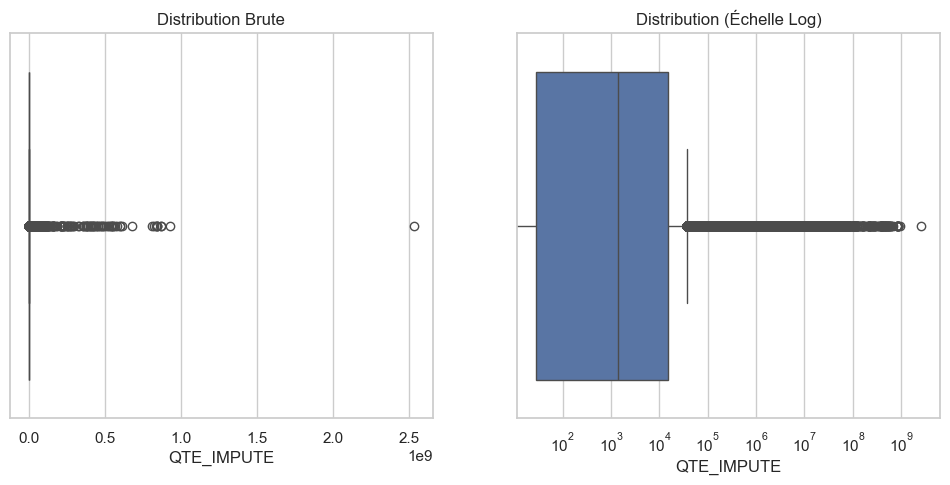

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Graphique 1 : Distribution brute (probablement illisible à cause des outliers)
plt.subplot(1, 2, 1)
sns.boxplot(x=raw_data['QTE_IMPUTE'])
plt.title('Distribution Brute')

# Graphique 2 : Distribution avec échelle logarithmique pour voir la vraie forme
plt.subplot(1, 2, 2)
sns.boxplot(x=raw_data['QTE_IMPUTE'])
plt.xscale('log')
plt.title('Distribution (Échelle Log)')

plt.show()

# **6- Multivariate Check:**

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = ['FOB', 'FRET', 'ASSURANCE', 'FRAIS_ACCESSOIRE', 'QUANTITE_DOMICILE', 'QTE_IMPUTE']
data_num = raw_data[cols_num]

matrice_corr = data_num.corr(method='spearman')

print(matrice_corr)

                       FOB     FRET  ASSURANCE  FRAIS_ACCESSOIRE  \
FOB                1.00000  0.37962    0.10449          -0.01190   
FRET               0.37962  1.00000    0.16916          -0.00409   
ASSURANCE          0.10449  0.16916    1.00000           0.00770   
FRAIS_ACCESSOIRE  -0.01190 -0.00409    0.00770           1.00000   
QUANTITE_DOMICILE  0.67868  0.33888    0.06894          -0.02460   
QTE_IMPUTE         0.50724  0.29048    0.04427          -0.01842   

                   QUANTITE_DOMICILE  QTE_IMPUTE  
FOB                          0.67868     0.50724  
FRET                         0.33888     0.29048  
ASSURANCE                    0.06894     0.04427  
FRAIS_ACCESSOIRE            -0.02460    -0.01842  
QUANTITE_DOMICILE            1.00000     0.71453  
QTE_IMPUTE                   0.71453     1.00000  


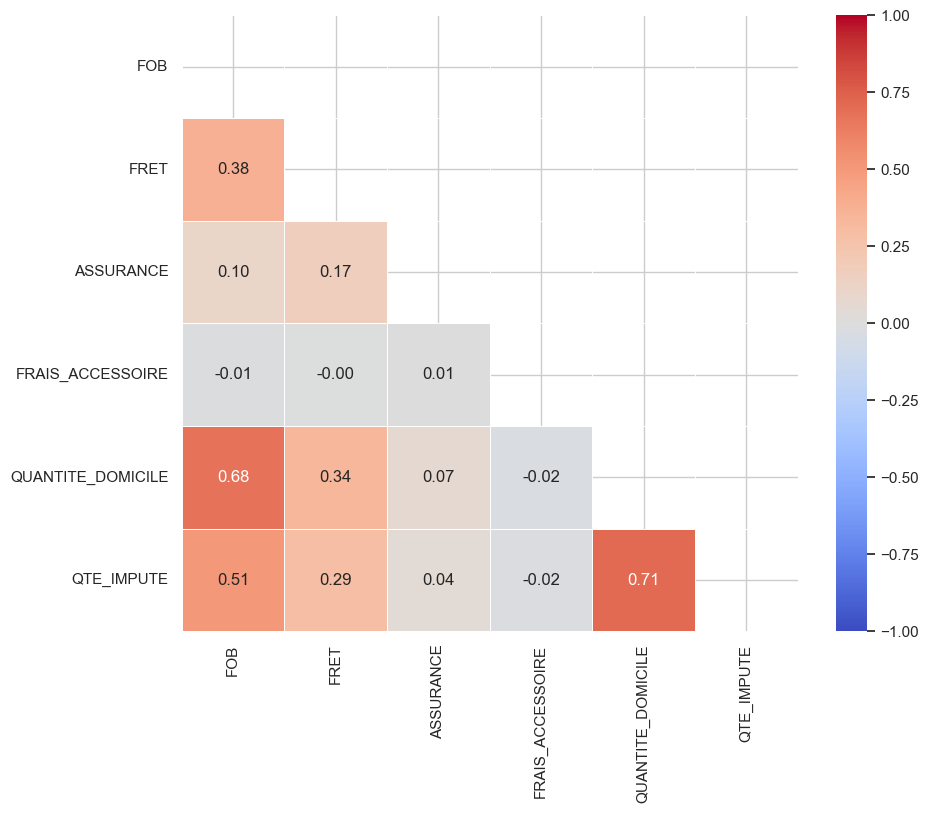

In [32]:
plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(matrice_corr, dtype=bool))

sns.heatmap(matrice_corr,
            mask=mask,
            annot=True,
            fmt=".2f", 
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            center=0,
            square=True,
            linewidths=.5)

plt.show()



# Problems

[ ]- target = QTE_IMPUTE --> problème de Régression



[ ]- drop ID et NUM_REGISTRO



[ ]- DATE_DOMICILIATION, DATE_ENREG_DO : object --> datetime



[ ]- ANNEE, MOIS: object --> int



[ ]- CODE_SH : int64  --> object ou category



[ ]- DEVISE: EUR = 71.18% et USD = 26.09% --> Convertir les montants associés en EUR dans une nouvelle colonne et supprimer le reste (3%)



[ ]- Supprimer la colonne DEVISE après avoir tout converti en EUR



[ ]- ASSURANCE, FRAIS_ACCESSOIRE: majorité = 0 --> ajouter de nouvelles colonnes booléennes: a_une_assurance(1,0) a_frais_accessoire(1,0)



[ ]- QUANTITE_DOMICILE : Codes système masqués sous des 9 répétitifs. --> Convertir ces valeurs exactes en (np.nan)



[ ]- Outliers in: FRET, FOB, QTE_IMPUTE, QUANTITE_DOMICILE --> transformation logarithmique (np.log1p) + StandardScaler



[ ]- Très Haute Cardinalité des variables catégorielles --> Si ce n'est pas utile, on supprime, sinon, Target Encoding ou NLP



[ ]- 576215 valeurs = 0 pour QTE_IMPUTE --> supprimer ces valeurs



[ ]- un Score d'asymétrie = 305.43 --> Appliquer une transformation logarithmique (np.log1p) sur QTE_IMPUTE



[ ]- Appliquer la fonction mathématique inverse np.expm1() sur QTE_IMPUTE predit par le model



[ ]- Golden features: QUANTITE_DOMICILE(0.71) + FOB(0.51)



[ ]- Drop DATE_IMPUTATION et DATE_ENREG_IMP



[ ]- L'Encodage Cyclique de MOIS a l'aide d'une fonction trigonométrique



[ ]- Regrouper les 12 mois sous forme de Trimestres Fiscaux



[ ]- Extraire la colone DELAI_ENREGISTREMENT (DATE_ENREG_DO - DATE_DOMICILIATION) 



**********************************************************************************************************************************
# TO-DO:


* Target = QTE_IMPUTE --> problème de Régression
* Golden features: QUANTITE_DOMICILE(0.71) + FOB(0.51)

## 1. Data Cleaning:
[X]- Drop ID, NUM_REGISTRO, DATE_IMPUTATION et DATE_ENREG_IMP

[ ]- Drop les 576215 valeurs = 0 dans QTE_IMPUTE

[X]- DATE_DOMICILIATION, DATE_ENREG_DO : object --> datetime

[X]- ANNEE, MOIS: object --> int

[X]- CODE_SH : int64  --> object ou category

[X]- QUANTITE_DOMICILE : Codes système masqués sous des 9 répétitifs. --> Convertir ces valeurs exactes en (np.nan)

## 2. Feature Engineering:
[X]- Extraire la colone DELAI_ENREGISTREMENT (DATE_ENREG_DO - DATE_DOMICILIATION) 

[X]- Regrouper les 12 mois sous forme de Trimestres Fiscaux

[X]- L'Encodage Cyclique de MOIS a l'aide d'une fonction trigonométrique

[X]- ASSURANCE, FRAIS_ACCESSOIRE: majorité = 0 --> ajouter de nouvelles colonnes booléennes: a_une_assurance(1,0) a_frais_accessoire(1,0)

[ ]- DEVISE: Convertir les montants en USD(26.09 %) en EUR(71.18 %) dans une nouvelle colonne et supprimer la colonne avec le reste(3%)

## 3. Data Preprocessing

[X]- Outliers in: FRET, FOB, QUANTITE_DOMICILE, QTE_IMPUTE --> transformation logarithmique (np.log1p) + StandardScaler

[X]- Très Haute Cardinalité des variables catégorielles --> Target Encoding

[ ]- Appliquer la fonction mathématique inverse np.expm1() sur QTE_IMPUTE predit par le model

# END